# Hybrid Detrending Forecasting — XGBoost vs Random Forest

**ML Engineer: Daffa (Product & Demand Strategy)**

Pipeline Hybrid Forecasting per cabang gerai, membandingkan **XGBoost** vs **Random Forest** sebagai model residu mikro.

## Pipeline
- **Section A:** Data Preparation (agregasi harian per cabang)
- **Section B:** Model Makro — Holt-Winters (seasonal_periods=7)
- **Section C:** Model Residu Mikro — XGBoost vs Random Forest
- **Section D:** Rekonstruksi & Evaluasi
- **Section E:** Forecast 90 Hari Ke Depan
- **Section F:** Export & Visualisasi

## Input
- `df_transaction_features.parquet`

## Output
- `models/macro_model_{branch}.joblib` — 10 model Holt-Winters
- `models/best_resid_model_{branch}.joblib` — 10 model ML terbaik per cabang
- `df_forecast_90days.parquet` — 900 baris (90 hari × 10 cabang)
- `forecast_evaluation_summary.json` — metadata evaluasi

## Import Library

In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import gc
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# Buat folder models jika belum ada
Path('models').mkdir(exist_ok=True)

print('Library imported.')

Library imported.


---
## SECTION A: DATA PREPARATION

In [2]:
gc.collect()

# ── A1. Load data ─────────────────────────────────────────────────────────
tx_table = pq.read_table(
    'df_transaction_features.parquet',
    columns=['transaction_id', 'city', 'created_at', 'final_amount',
             'basket_size', 'is_voucher_used_bool']
)
df_tx = tx_table.replace_schema_metadata({}).to_pandas()
del tx_table
gc.collect()

print(f'Loaded: {len(df_tx):,} rows')
print(f'Columns: {list(df_tx.columns)}')
print(f'Date range: {df_tx["created_at"].min()} to {df_tx["created_at"].max()}')

Loaded: 14,623,691 rows
Columns: ['transaction_id', 'city', 'created_at', 'final_amount', 'basket_size', 'is_voucher_used_bool']


Date range: 2023-07-01 07:00:00 to 2025-06-30 19:59:39


In [3]:
# ── A2. Agregasi harian per cabang ────────────────────────────────────────
df_tx['date'] = pd.to_datetime(df_tx['created_at']).dt.normalize()

df_daily = df_tx.groupby(['date', 'city'], as_index=False).agg(
    total_transactions=('transaction_id', 'count'),
    total_revenue=('final_amount', 'sum'),
    avg_basket=('basket_size', 'mean'),
    voucher_rate=('is_voucher_used_bool', 'mean')
)

df_daily = df_daily.sort_values(['city', 'date']).reset_index(drop=True)
df_daily.rename(columns={'date': 'created_at'}, inplace=True)

# Bersihkan memori
del df_tx
gc.collect()

print(f'Daily aggregated: {len(df_daily):,} rows')
print(f'Cities: {sorted(df_daily["city"].unique())}')
print(f'Date range: {df_daily["created_at"].min()} to {df_daily["created_at"].max()}')
print(f'Days per city: ~{len(df_daily) // df_daily["city"].nunique()}')

Daily aggregated: 7,310 rows
Cities: ['Alam Tun Hussein Onn', 'Bandar Seri Mulia', 'Damansara Saujana', 'Kampung Changkat', 'Kondominium Putra', 'PJS8', 'Seksyen 21', 'Taman Damansara', 'USJ 57W', 'USJ 89q']
Date range: 2023-07-01 00:00:00 to 2025-06-30 00:00:00
Days per city: ~731


In [4]:
# ── A3. Feature Engineering ───────────────────────────────────────────────
# Fitur kalender (TIDAK ada autoregresif — mencegah error propagation)
df_daily['day_of_week'] = df_daily['created_at'].dt.dayofweek   # 0=Mon .. 6=Sun
df_daily['month'] = df_daily['created_at'].dt.month             # 1-12
df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

TARGET = 'total_transactions'
FEATURES_RESIDUAL = ['day_of_week', 'month', 'is_weekend', 'voucher_rate']
FORECAST_DAYS = 90

cities = sorted(df_daily['city'].unique())
print(f'Features: {FEATURES_RESIDUAL}')
print(f'Target: {TARGET}')
print(f'Cities ({len(cities)}): {cities}')
print(f'\nSample:')
print(df_daily.head())

Features: ['day_of_week', 'month', 'is_weekend', 'voucher_rate']
Target: total_transactions
Cities (10): ['Alam Tun Hussein Onn', 'Bandar Seri Mulia', 'Damansara Saujana', 'Kampung Changkat', 'Kondominium Putra', 'PJS8', 'Seksyen 21', 'Taman Damansara', 'USJ 57W', 'USJ 89q']

Sample:
  created_at                  city  total_transactions  total_revenue  \
0 2023-07-01  Alam Tun Hussein Onn                1970        61630.5   
1 2023-07-02  Alam Tun Hussein Onn                1963        59824.0   
2 2023-07-03  Alam Tun Hussein Onn                2005        62485.5   
3 2023-07-04  Alam Tun Hussein Onn                1963        60488.5   
4 2023-07-05  Alam Tun Hussein Onn                2059        64115.5   

   avg_basket  voucher_rate  day_of_week  month  is_weekend  
0    3.765482           0.0            5      7           1  
1    3.691798           0.0            6      7           1  
2    3.746135           0.0            0      7           0  
3    3.711156           0.0 

---
## SECTION B: MODEL MAKRO — Holt-Winters (Per Cabang)

Menggunakan `seasonal_periods=7` (mingguan) karena pola kopi lebih dipengaruhi hari dalam seminggu.

In [5]:
gc.collect()

SEASONAL_PERIOD = 7  # mingguan
TRAIN_RATIO = 0.8

hw_models = {}       # menyimpan model Holt-Winters per cabang
hw_fitted_train = {} # fitted values pada train
hw_fitted_test = {}  # predicted values pada test
train_residuals = {} # residu pada train set
cutoff_dates = {}    # tanggal cutoff per cabang

print('=' * 60)
print('SECTION B: Holt-Winters Macro Model (Per Cabang)')
print('=' * 60)

for city in cities:
    series = (
        df_daily[df_daily['city'] == city]
        .set_index('created_at')[TARGET]
        .sort_index()
    )
    series = series.asfreq('D')
    series = series.interpolate(method='linear')
    
    # Temporal split 80/20
    n_train = int(len(series) * TRAIN_RATIO)
    train_series = series.iloc[:n_train]
    test_series = series.iloc[n_train:]
    cutoff_dates[city] = train_series.index[-1]
    
    # Fit Holt-Winters
    model = ExponentialSmoothing(
        train_series,
        trend='add',
        seasonal='add',
        seasonal_periods=SEASONAL_PERIOD
    ).fit(optimized=True)
    
    hw_models[city] = model
    
    # Fitted pada train
    hw_fitted_train[city] = model.fittedvalues
    
    # Predict pada test
    hw_fitted_test[city] = model.forecast(len(test_series))
    hw_fitted_test[city].index = test_series.index
    
    # Residu train
    train_residuals[city] = train_series - model.fittedvalues
    
    print(f'  {city}: train={n_train}, test={len(test_series)}, '
          f'cutoff={cutoff_dates[city].date()}')

print(f'\nHolt-Winters fitted for {len(cities)} branches.')
gc.collect()


SECTION B: Holt-Winters Macro Model (Per Cabang)


  Alam Tun Hussein Onn: train=584, test=147, cutoff=2025-02-03
  Bandar Seri Mulia: train=584, test=147, cutoff=2025-02-03


  Damansara Saujana: train=584, test=147, cutoff=2025-02-03
  Kampung Changkat: train=584, test=147, cutoff=2025-02-03


  Kondominium Putra: train=584, test=147, cutoff=2025-02-03
  PJS8: train=584, test=147, cutoff=2025-02-03


  Seksyen 21: train=584, test=147, cutoff=2025-02-03
  Taman Damansara: train=584, test=147, cutoff=2025-02-03


  USJ 57W: train=584, test=147, cutoff=2025-02-03
  USJ 89q: train=584, test=147, cutoff=2025-02-03

Holt-Winters fitted for 10 branches.


0

---
## SECTION C: MODEL RESIDU MIKRO — XGBoost vs Random Forest (Per Cabang)

In [6]:
gc.collect()

xgb_models = {}
rf_models = {}

print('=' * 60)
print('SECTION C: XGBoost vs Random Forest on Residuals')
print('=' * 60)

for city in cities:
    # ── Prepare residual training data ────────────────────────────────────
    city_train = df_daily[
        (df_daily['city'] == city) &
        (df_daily['created_at'] <= cutoff_dates[city])
    ].copy()
    
    city_train = city_train.set_index('created_at').sort_index()
    city_train['residual'] = train_residuals[city].reindex(city_train.index)
    city_train = city_train.dropna(subset=['residual'])
    
    X_train = city_train[FEATURES_RESIDUAL]
    y_train = city_train['residual']
    
    # ── XGBoost ───────────────────────────────────────────────────────────
    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    xgb_models[city] = xgb_model
    
    # ── Random Forest ─────────────────────────────────────────────────────
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    rf_models[city] = rf_model
    
    print(f'  {city}: trained XGB + RF on {len(X_train)} residual samples')
    gc.collect()

print(f'\nAll models trained for {len(cities)} branches.')

SECTION C: XGBoost vs Random Forest on Residuals


  Alam Tun Hussein Onn: trained XGB + RF on 584 residual samples


  Bandar Seri Mulia: trained XGB + RF on 584 residual samples


  Damansara Saujana: trained XGB + RF on 584 residual samples


  Kampung Changkat: trained XGB + RF on 584 residual samples


...

  PJS8: trained XGB + RF on 584 residual samples


  Seksyen 21: trained XGB + RF on 584 residual samples


  Taman Damansara: trained XGB + RF on 584 residual samples


  USJ 57W: trained XGB + RF on 584 residual samples


  USJ 89q: trained XGB + RF on 584 residual samples

All models trained for 10 branches.


---
## SECTION D: REKONSTRUKSI & EVALUASI

In [7]:
gc.collect()

evaluation_results = []
best_model_per_branch = {}

print('=' * 60)
print('SECTION D: Evaluation on Test Set')
print('=' * 60)
print(f'{"Branch":25s} | {"MAE_XGB":>8s} {"RMSE_XGB":>9s} | {"MAE_RF":>8s} {"RMSE_RF":>9s} | {"Best":>5s}')
print('-' * 85)

for city in cities:
    # Test data
    city_test = df_daily[
        (df_daily['city'] == city) &
        (df_daily['created_at'] > cutoff_dates[city])
    ].copy()
    city_test = city_test.set_index('created_at').sort_index()
    
    y_true = city_test[TARGET].values
    
    # Macro prediction pada test
    macro_pred = hw_fitted_test[city].reindex(city_test.index).values
    
    X_test = city_test[FEATURES_RESIDUAL]
    
    # ── XGBoost hybrid ────────────────────────────────────────────────────
    xgb_resid_pred = xgb_models[city].predict(X_test)
    y_pred_xgb = macro_pred + xgb_resid_pred
    
    mae_xgb = mean_absolute_error(y_true, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_true, y_pred_xgb))
    
    # ── Random Forest hybrid ──────────────────────────────────────────────
    rf_resid_pred = rf_models[city].predict(X_test)
    y_pred_rf = macro_pred + rf_resid_pred
    
    mae_rf = mean_absolute_error(y_true, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred_rf))
    
    # ── Pilih model terbaik (RMSE terendah) ───────────────────────────────
    best = 'XGB' if rmse_xgb <= rmse_rf else 'RF'
    best_model_per_branch[city] = best
    
    evaluation_results.append({
        'branch': city,
        'MAE_XGB': round(mae_xgb, 2),
        'RMSE_XGB': round(rmse_xgb, 2),
        'MAE_RF': round(mae_rf, 2),
        'RMSE_RF': round(rmse_rf, 2),
        'best_model': best
    })
    
    print(f'{city:25s} | {mae_xgb:8.2f} {rmse_xgb:9.2f} | {mae_rf:8.2f} {rmse_rf:9.2f} | {best:>5s}')

df_eval = pd.DataFrame(evaluation_results)
print(f'\n=== Summary ===')
print(f'XGB wins: {(df_eval["best_model"] == "XGB").sum()} branches')
print(f'RF wins:  {(df_eval["best_model"] == "RF").sum()} branches')
print(f'Avg MAE XGB: {df_eval["MAE_XGB"].mean():.2f}  |  Avg MAE RF: {df_eval["MAE_RF"].mean():.2f}')
print(f'Avg RMSE XGB: {df_eval["RMSE_XGB"].mean():.2f}  |  Avg RMSE RF: {df_eval["RMSE_RF"].mean():.2f}')


SECTION D: Evaluation on Test Set
Branch                    |  MAE_XGB  RMSE_XGB |   MAE_RF   RMSE_RF |  Best
-------------------------------------------------------------------------------------
Alam Tun Hussein Onn      |    35.63     44.21 |    35.84     44.39 |   XGB
Bandar Seri Mulia         |    34.02     43.82 |    33.94     44.00 |   XGB
Damansara Saujana         |    35.99     43.49 |    35.96     43.47 |    RF


Kampung Changkat          |    34.49     42.11 |    35.01     42.87 |   XGB
Kondominium Putra         |    36.86     44.94 |    36.86     44.77 |    RF
PJS8                      |    35.93     45.14 |    36.64     45.84 |   XGB
Seksyen 21                |    33.37     41.49 |    33.44     41.49 |    RF


Taman Damansara           |    33.93     42.43 |    34.05     42.67 |   XGB
USJ 57W                   |    36.52     44.10 |    36.34     43.91 |    RF
USJ 89q                   |    34.00     42.81 |    34.02     42.89 |   XGB

=== Summary ===
XGB wins: 6 branches
RF wins:  4 branches
Avg MAE XGB: 35.07  |  Avg MAE RF: 35.21
Avg RMSE XGB: 43.45  |  Avg RMSE RF: 43.63


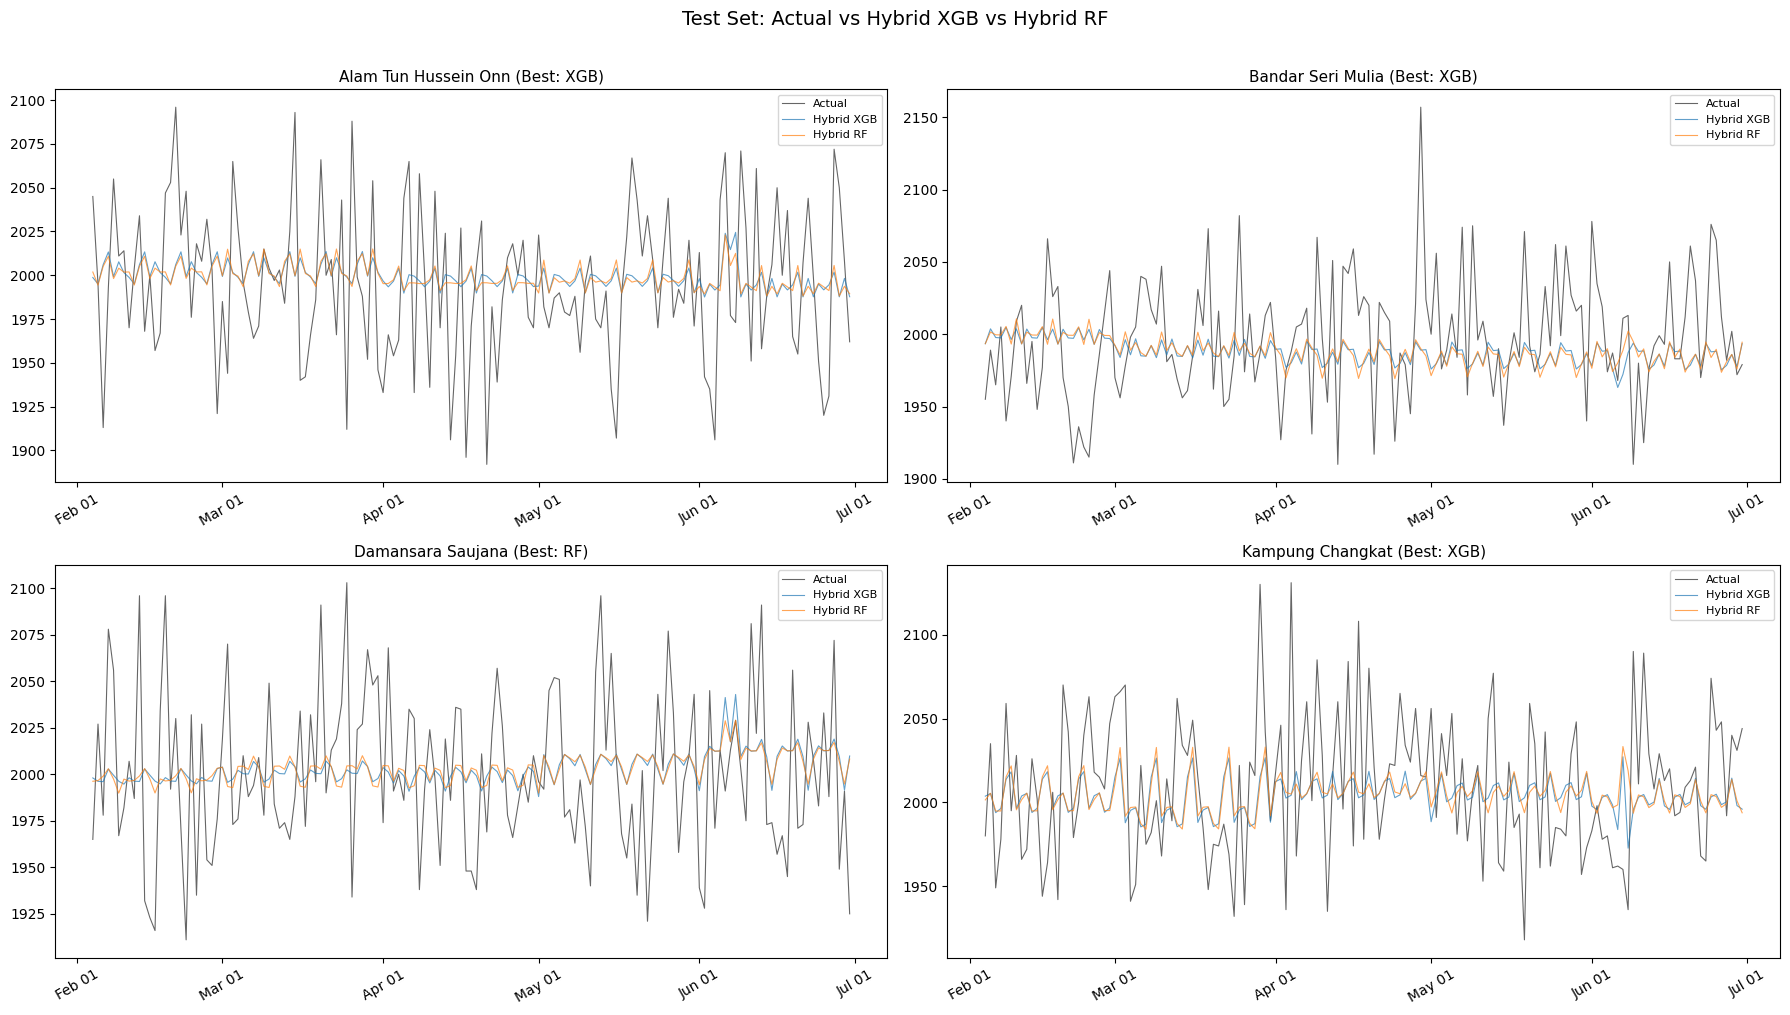

In [8]:
# ── D2. Visualisasi Prediksi vs Aktual (test set, 4 cabang pertama) ──────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, city in enumerate(cities[:4]):
    ax = axes[idx]
    
    city_test = df_daily[
        (df_daily['city'] == city) &
        (df_daily['created_at'] > cutoff_dates[city])
    ].sort_values('created_at')
    
    dates = city_test['created_at']
    y_true = city_test[TARGET].values
    
    macro_pred = hw_fitted_test[city].reindex(city_test.set_index('created_at').index).values
    xgb_pred = macro_pred + xgb_models[city].predict(city_test[FEATURES_RESIDUAL])
    rf_pred = macro_pred + rf_models[city].predict(city_test[FEATURES_RESIDUAL])
    
    ax.plot(dates, y_true, 'k-', alpha=0.6, label='Actual', linewidth=0.8)
    ax.plot(dates, xgb_pred, '-', alpha=0.7, label='Hybrid XGB', linewidth=0.8)
    ax.plot(dates, rf_pred, '-', alpha=0.7, label='Hybrid RF', linewidth=0.8)
    
    best = best_model_per_branch[city]
    ax.set_title(f'{city} (Best: {best})', fontsize=11)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Test Set: Actual vs Hybrid XGB vs Hybrid RF', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## SECTION E: FORECAST 90 HARI KE DEPAN

In [9]:
gc.collect()

print('=' * 60)
print('SECTION E: 90-Day Forecast')
print('=' * 60)

all_forecasts = []

for city in cities:
    # ── E1. Re-fit Holt-Winters pada SELURUH data ────────────────────────
    full_series = (
        df_daily[df_daily['city'] == city]
        .set_index('created_at')[TARGET]
        .sort_index()
        .asfreq('D')
        .interpolate(method='linear')
    )
    
    full_hw = ExponentialSmoothing(
        full_series,
        trend='add',
        seasonal='add',
        seasonal_periods=SEASONAL_PERIOD
    ).fit(optimized=True)
    
    # Simpan model makro
    macro_path = f'models/macro_model_{city.replace(" ", "_")}.joblib'
    joblib.dump(full_hw, macro_path)
    
    # ── E2. Forecast makro 90 hari ────────────────────────────────────────
    macro_forecast = full_hw.forecast(FORECAST_DAYS)
    
    # ── E3. Buat fitur kalender 90 hari ke depan ──────────────────────────
    last_date = full_series.index[-1]
    future_dates = pd.date_range(
        start=last_date + timedelta(days=1),
        periods=FORECAST_DAYS,
        freq='D'
    )
    
    # Voucher rate = rata-rata historis cabang
    avg_voucher = df_daily[df_daily['city'] == city]['voucher_rate'].mean()
    
    df_future_feat = pd.DataFrame({
        'day_of_week': future_dates.dayofweek,
        'month': future_dates.month,
        'is_weekend': (future_dates.dayofweek >= 5).astype(int),
        'voucher_rate': avg_voucher
    })
    
    # ── E4. Prediksi residu dengan model terbaik ──────────────────────────
    best = best_model_per_branch[city]
    if best == 'XGB':
        best_resid_model = xgb_models[city]
    else:
        best_resid_model = rf_models[city]
    
    # Simpan model residu terbaik
    resid_path = f'models/best_resid_model_{city.replace(" ", "_")}.joblib'
    joblib.dump(best_resid_model, resid_path)
    
    resid_forecast = best_resid_model.predict(df_future_feat)
    
    # ── E5. Rekonstruksi total forecast ───────────────────────────────────
    total_forecast = macro_forecast.values + resid_forecast
    
    # Clamp agar tidak negatif
    total_forecast = np.maximum(total_forecast, 0)
    
    for i, d in enumerate(future_dates):
        all_forecasts.append({
            'branch': city,
            'created_at': d,
            'total_transactions': round(total_forecast[i]),
            'macro_component': round(macro_forecast.values[i], 2),
            'resid_component': round(resid_forecast[i], 2),
            'best_model': best
        })
    
    print(f'  {city}: forecast generated (model={best}), '
          f'avg={total_forecast.mean():.0f} tx/day')
    gc.collect()

df_forecast = pd.DataFrame(all_forecasts)
print(f'\nTotal forecast rows: {len(df_forecast):,}')
print(f'Branches: {df_forecast["branch"].nunique()}')
print(f'Date range: {df_forecast["created_at"].min()} to {df_forecast["created_at"].max()}')

SECTION E: 90-Day Forecast
  Alam Tun Hussein Onn: forecast generated (model=XGB), avg=2002 tx/day


  Bandar Seri Mulia: forecast generated (model=XGB), avg=1995 tx/day


  Damansara Saujana: forecast generated (model=RF), avg=2004 tx/day


  Kampung Changkat: forecast generated (model=XGB), avg=2008 tx/day


  Kondominium Putra: forecast generated (model=RF), avg=2001 tx/day


  PJS8: forecast generated (model=XGB), avg=1996 tx/day


  Seksyen 21: forecast generated (model=RF), avg=2002 tx/day


  Taman Damansara: forecast generated (model=XGB), avg=2000 tx/day


  USJ 57W: forecast generated (model=RF), avg=1995 tx/day


  USJ 89q: forecast generated (model=XGB), avg=1993 tx/day

Total forecast rows: 900
Branches: 10
Date range: 2025-07-01 00:00:00 to 2025-09-28 00:00:00


---
## SECTION F: EXPORT & VISUALISASI

In [10]:
# ── F1. Export parquet ─────────────────────────────────────────────────────
df_forecast.to_parquet('df_forecast_90days.parquet', index=False)
print('Saved: df_forecast_90days.parquet')

# ── F2. Export evaluation JSON ────────────────────────────────────────────
eval_summary = {
    'model_type': 'Hybrid Detrending (Holt-Winters + ML Residual)',
    'seasonal_period': SEASONAL_PERIOD,
    'forecast_days': FORECAST_DAYS,
    'train_ratio': TRAIN_RATIO,
    'features': FEATURES_RESIDUAL,
    'per_branch': evaluation_results,
    'best_model_per_branch': best_model_per_branch,
    'aggregate': {
        'avg_MAE_XGB': round(df_eval['MAE_XGB'].mean(), 2),
        'avg_RMSE_XGB': round(df_eval['RMSE_XGB'].mean(), 2),
        'avg_MAE_RF': round(df_eval['MAE_RF'].mean(), 2),
        'avg_RMSE_RF': round(df_eval['RMSE_RF'].mean(), 2),
        'xgb_wins': int((df_eval['best_model'] == 'XGB').sum()),
        'rf_wins': int((df_eval['best_model'] == 'RF').sum())
    }
}

with open('forecast_evaluation_summary.json', 'w', encoding='utf-8') as f:
    json.dump(eval_summary, f, indent=2, ensure_ascii=False)
print('Saved: forecast_evaluation_summary.json')

# ── F3. Tabel ringkasan ───────────────────────────────────────────────────
print('\n=== Evaluation Summary ===')
print(df_eval.to_string(index=False))

Saved: df_forecast_90days.parquet
Saved: forecast_evaluation_summary.json

=== Evaluation Summary ===
              branch  MAE_XGB  RMSE_XGB  MAE_RF  RMSE_RF best_model
Alam Tun Hussein Onn    35.63     44.21   35.84    44.39        XGB
   Bandar Seri Mulia    34.02     43.82   33.94    44.00        XGB
   Damansara Saujana    35.99     43.49   35.96    43.47         RF
    Kampung Changkat    34.49     42.11   35.01    42.87        XGB
   Kondominium Putra    36.86     44.94   36.86    44.77         RF
                PJS8    35.93     45.14   36.64    45.84        XGB
          Seksyen 21    33.37     41.49   33.44    41.49         RF
     Taman Damansara    33.93     42.43   34.05    42.67        XGB
             USJ 57W    36.52     44.10   36.34    43.91         RF
             USJ 89q    34.00     42.81   34.02    42.89        XGB


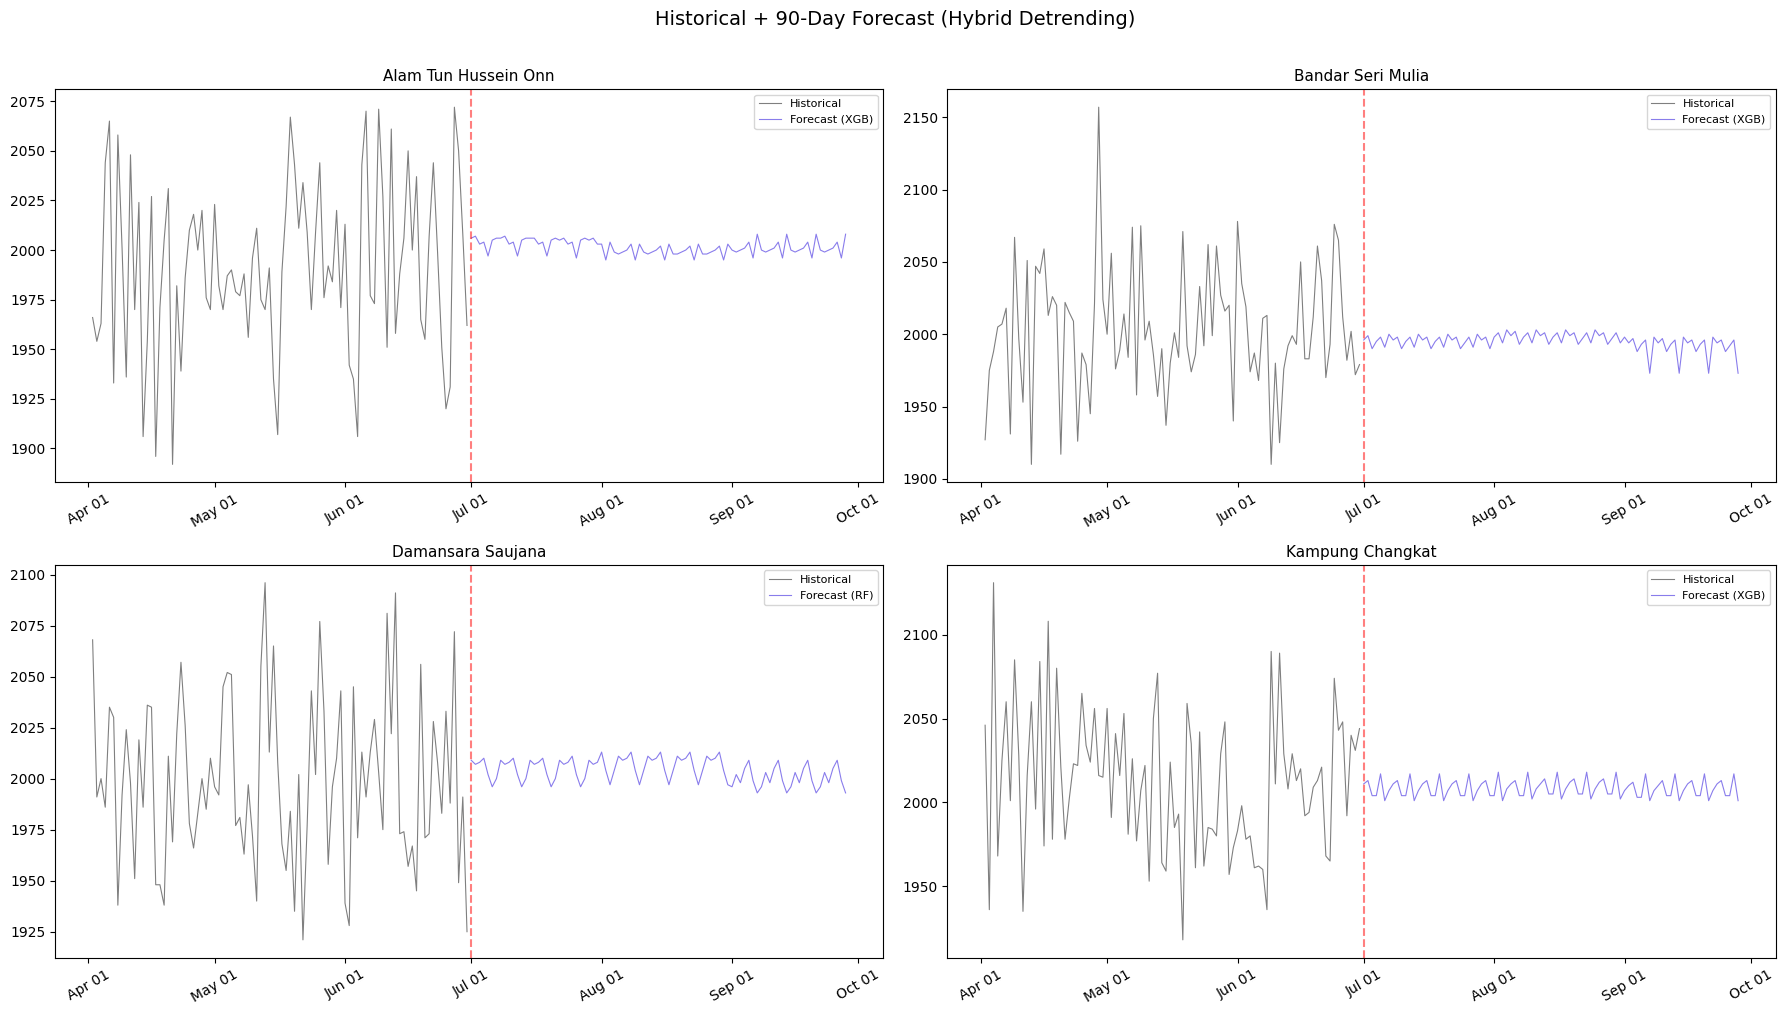

In [11]:
# ── F4. Visualisasi forecast 90 hari (4 cabang pertama) ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, city in enumerate(cities[:4]):
    ax = axes[idx]
    
    # Historical (last 90 days)
    hist = df_daily[df_daily['city'] == city].tail(90)
    ax.plot(hist['created_at'], hist[TARGET], 'k-', alpha=0.5,
            label='Historical', linewidth=0.8)
    
    # Forecast
    fc = df_forecast[df_forecast['branch'] == city]
    ax.plot(fc['created_at'], fc['total_transactions'], '-',
            color='#6C5CE7', alpha=0.8, label=f'Forecast ({best_model_per_branch[city]})',
            linewidth=0.8)
    
    # Vertical line at forecast start
    ax.axvline(x=fc['created_at'].min(), color='red', linestyle='--', alpha=0.5)
    
    ax.set_title(f'{city}', fontsize=11)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Historical + 90-Day Forecast (Hybrid Detrending)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

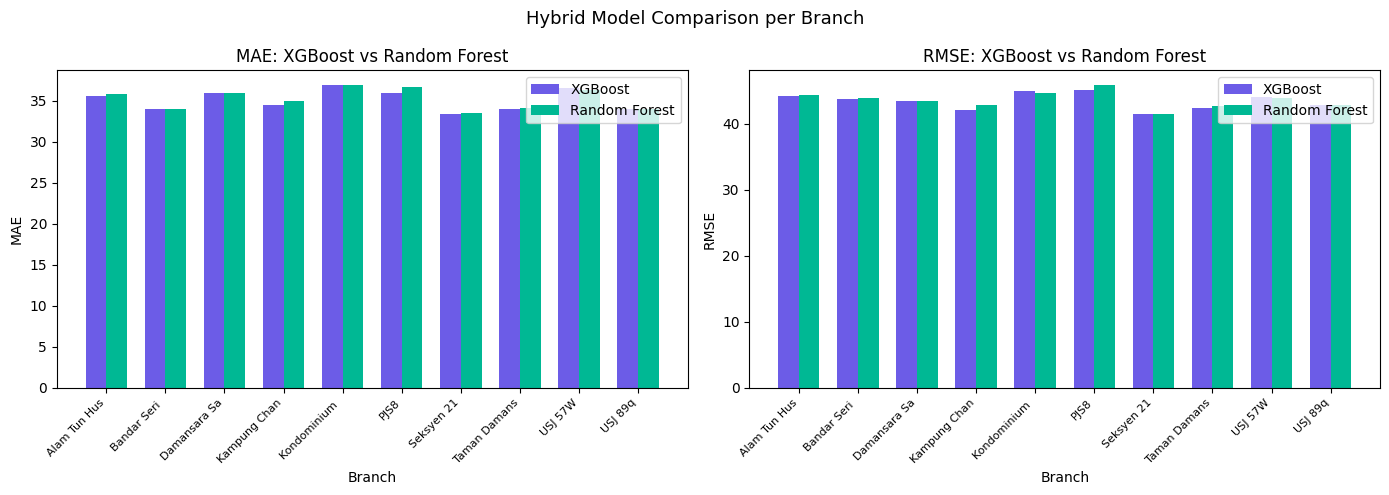

In [12]:
# ── F5. Perbandingan XGBoost vs RF bar chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(cities))
width = 0.35

# MAE comparison
axes[0].bar(x - width/2, df_eval['MAE_XGB'], width, label='XGBoost', color='#6C5CE7')
axes[0].bar(x + width/2, df_eval['MAE_RF'], width, label='Random Forest', color='#00B894')
axes[0].set_xlabel('Branch')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE: XGBoost vs Random Forest')
axes[0].set_xticks(x)
axes[0].set_xticklabels([c[:12] for c in cities], rotation=45, ha='right', fontsize=8)
axes[0].legend()

# RMSE comparison
axes[1].bar(x - width/2, df_eval['RMSE_XGB'], width, label='XGBoost', color='#6C5CE7')
axes[1].bar(x + width/2, df_eval['RMSE_RF'], width, label='Random Forest', color='#00B894')
axes[1].set_xlabel('Branch')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE: XGBoost vs Random Forest')
axes[1].set_xticks(x)
axes[1].set_xticklabels([c[:12] for c in cities], rotation=45, ha='right', fontsize=8)
axes[1].legend()

plt.suptitle('Hybrid Model Comparison per Branch', fontsize=13)
plt.tight_layout()
plt.show()

---
## Assertions & Validasi

In [13]:
print('=== Running Assertions ===')

# 1. Tepat 900 baris (90 hari x 10 cabang)
expected_rows = FORECAST_DAYS * len(cities)
assert len(df_forecast) == expected_rows, \
    f'FAIL: Expected {expected_rows} rows, got {len(df_forecast)}'
print(f'[PASS] Forecast rows: {len(df_forecast)} == {expected_rows}')

# 2. Semua total_transactions >= 0
assert (df_forecast['total_transactions'] >= 0).all(), \
    'FAIL: Negative transaction predictions found'
print('[PASS] All total_transactions >= 0')

# 3. Semua 10 cabang tercakup
assert df_forecast['branch'].nunique() == len(cities), \
    f'FAIL: Expected {len(cities)} branches'
print(f'[PASS] Branches: {df_forecast["branch"].nunique()} == {len(cities)}')

# 4. Evaluasi mencakup semua cabang
assert len(df_eval) == len(cities), \
    f'FAIL: Evaluation missing branches'
print(f'[PASS] Evaluation covers all {len(cities)} branches')

# 5. MAE & RMSE finite (tidak NaN/Inf)
for col in ['MAE_XGB', 'RMSE_XGB', 'MAE_RF', 'RMSE_RF']:
    assert np.isfinite(df_eval[col]).all(), f'FAIL: {col} has non-finite values'
    print(f'[PASS] {col}: all finite')

# 6. Model files exist
for city in cities:
    safe_name = city.replace(' ', '_')
    assert Path(f'models/macro_model_{safe_name}.joblib').exists(), \
        f'FAIL: macro model missing for {city}'
    assert Path(f'models/best_resid_model_{safe_name}.joblib').exists(), \
        f'FAIL: resid model missing for {city}'
print(f'[PASS] All {len(cities)*2} model files saved')

# 7. Output files
assert Path('df_forecast_90days.parquet').exists()
assert Path('forecast_evaluation_summary.json').exists()
print('[PASS] Output files exist')

print('\n=== All Assertions Passed ===')

=== Running Assertions ===
[PASS] Forecast rows: 900 == 900
[PASS] All total_transactions >= 0
[PASS] Branches: 10 == 10
[PASS] Evaluation covers all 10 branches
[PASS] MAE_XGB: all finite
[PASS] RMSE_XGB: all finite
[PASS] MAE_RF: all finite
[PASS] RMSE_RF: all finite
[PASS] All 20 model files saved
[PASS] Output files exist

=== All Assertions Passed ===


In [14]:
# ── Final Summary ─────────────────────────────────────────────────────────
print('=' * 60)
print('HYBRID FORECASTING — SELESAI')
print('=' * 60)
print(f'Forecast: {FORECAST_DAYS} hari x {len(cities)} cabang = {len(df_forecast)} rows')
print(f'Seasonal period: {SEASONAL_PERIOD} (mingguan)')
print(f'\nModel terbaik per cabang:')
for city in cities:
    print(f'  {city}: {best_model_per_branch[city]}')
print(f'\nFiles exported:')
print(f'  - df_forecast_90days.parquet')
print(f'  - forecast_evaluation_summary.json')
print(f'  - models/ ({len(cities)*2} files)')

gc.collect()
print('\nDone.')

HYBRID FORECASTING — SELESAI
Forecast: 90 hari x 10 cabang = 900 rows
Seasonal period: 7 (mingguan)

Model terbaik per cabang:
  Alam Tun Hussein Onn: XGB
  Bandar Seri Mulia: XGB
  Damansara Saujana: RF
  Kampung Changkat: XGB
  Kondominium Putra: RF
  PJS8: XGB
  Seksyen 21: RF
  Taman Damansara: XGB
  USJ 57W: RF
  USJ 89q: XGB

Files exported:
  - df_forecast_90days.parquet
  - forecast_evaluation_summary.json
  - models/ (20 files)

Done.
